# NOAA Storm Events — Consolidación, EDA y dataset limpio maestro

Esta notebook consolida los archivos CSV del *Storm Events Database* de NOAA distribuidos en múltiples carpetas y realiza una exploración inicial de los datos.

## Objetivo de esta notebook

1. Consolidar los archivos históricos de NOAA.
2. Limpiar fechas y montos de daño.
3. Analizar faltantes, distribución temporal, daños y variables relevantes.
4. Crear features determinísticas útiles para experimentos posteriores.
5. Exportar un **dataset limpio maestro**, sin aplicar encoding, escalado ni imputaciones basadas en estadísticas globales.

> El split, la imputación, el encoding, el escalado y cualquier transformación que aprenda parámetros de los datos deben realizarse en notebooks posteriores usando únicamente el conjunto de entrenamiento.

**Supuestos:**
- Los archivos conservan el formato y los nombres originales de NOAA (`StormEvents_details-*.csv`, `StormEvents_locations-*.csv`, `StormEvents_fatalities-*.csv`), aunque estén descomprimidos.
- Las tres categorías se vinculan mediante `EVENT_ID`.


## 1. Configuración

In [7]:
import os
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid', context='notebook')

# Carpetas que contienen los CSV históricos.
DATA_DIRS = [
    Path('../datasets/1970'),
    Path('../datasets/1971-1990'),
    Path('../datasets/1991-2010'),
    Path('../datasets/2011-2026'),
]

OUTPUT_DIR = Path('../datasets')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Carga y consolidación

Se recorren todas las carpetas y se clasifican los archivos por prefijo. Cada tipo se concatena en un único DataFrame.

In [8]:
FILE_PATTERNS = {
    'details':    re.compile(r'StormEvents_details-.*\.csv$',    re.IGNORECASE),
    'locations':  re.compile(r'StormEvents_locations-.*\.csv$',  re.IGNORECASE),
    'fatalities': re.compile(r'StormEvents_fatalities-.*\.csv$', re.IGNORECASE),
}

def discover_files(dirs):
    """Devuelve un dict {tipo: [paths]} con todos los CSV encontrados."""
    found = {k: [] for k in FILE_PATTERNS}
    for d in dirs:
        if not d.exists():
            print(f'[aviso] carpeta no encontrada: {d}')
            continue
        for f in d.glob('*.csv'):
            for kind, pattern in FILE_PATTERNS.items():
                if pattern.search(f.name):
                    found[kind].append(f)
                    break
    for kind, paths in found.items():
        print(f'{kind:<11}: {len(paths)} archivo(s)')
    return found

files = discover_files(DATA_DIRS)

details    : 57 archivo(s)
locations  : 57 archivo(s)
fatalities : 57 archivo(s)


In [9]:
def load_concat(paths, label):
    """Concatena una lista de CSV reportando filas por archivo."""
    frames = []
    for p in sorted(paths):
        df = pd.read_csv(p, low_memory=False)
        frames.append(df)
        print(f'  {p.name}: {len(df):,} filas')
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    print(f'{label} total: {len(out):,} filas\n')
    return out

print('=== DETAILS ===')
details = load_concat(files['details'], 'details')
print('=== LOCATIONS ===')
locations = load_concat(files['locations'], 'locations')
print('=== FATALITIES ===')
fatalities = load_concat(files['fatalities'], 'fatalities')

=== DETAILS ===
  StormEvents_details-ftp_v1.0_d1970_c20260323.csv: 3,215 filas
  StormEvents_details-ftp_v1.0_d1971_c20260323.csv: 3,471 filas
  StormEvents_details-ftp_v1.0_d1972_c20260323.csv: 2,171 filas
  StormEvents_details-ftp_v1.0_d1973_c20260323.csv: 4,453 filas
  StormEvents_details-ftp_v1.0_d1974_c20260323.csv: 5,375 filas
  StormEvents_details-ftp_v1.0_d1975_c20260323.csv: 4,975 filas
  StormEvents_details-ftp_v1.0_d1976_c20260323.csv: 3,768 filas
  StormEvents_details-ftp_v1.0_d1977_c20260323.csv: 3,728 filas
  StormEvents_details-ftp_v1.0_d1978_c20260323.csv: 3,657 filas
  StormEvents_details-ftp_v1.0_d1979_c20260323.csv: 4,279 filas
  StormEvents_details-ftp_v1.0_d1980_c20260323.csv: 6,136 filas
  StormEvents_details-ftp_v1.0_d1981_c20260323.csv: 4,517 filas
  StormEvents_details-ftp_v1.0_d1982_c20260323.csv: 7,126 filas
  StormEvents_details-ftp_v1.0_d1983_c20260323.csv: 8,322 filas
  StormEvents_details-ftp_v1.0_d1984_c20260323.csv: 7,335 filas
  StormEvents_details-ft

/tmp/ipykernel_16840/1654204122.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat(frames, ignore_index=True)


## 3. Limpieza y enriquecimiento

- Conversión de fechas.
- Normalización de columnas de daños (`DAMAGE_PROPERTY`, `DAMAGE_CROPS`) que vienen como strings con sufijos `K`, `M`, `B`.
- Eliminación de duplicados por `EVENT_ID`.

In [10]:
def parse_damage(value):
    """Convierte montos de daño de NOAA a float.

    Distingue tres casos:
      - vacío / no reportado   -> np.nan  (FALTANTE genuino)
      - cero explícito ('0')   -> 0.0     (SIN daño)
      - valor con sufijo K/M/B -> float escalado
    """
    if pd.isna(value):
        return np.nan
    s = str(value).strip().upper().replace(',', '')
    if s in ('', 'NAN', 'NONE'):
        return np.nan          # antes devolvía 0.0 -> colapsaba faltante con cero
    if s in ('0', '0.0', '0.00', '0K', '0M', '0B'):
        return 0.0
    multipliers = {'K': 1e3, 'M': 1e6, 'B': 1e9, 'T': 1e12, 'H': 1e2}
    if s[-1] in multipliers:
        try:
            return float(s[:-1]) * multipliers[s[-1]]
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

# Fechas — reconstrucción desde columnas numéricas para evitar bug del año de 2 dígitos
def build_datetime(df, prefix):
    """Reconstruye datetime desde columnas numéricas del CSV de NOAA."""
    ym  = df[f'{prefix}_YEARMONTH'].astype('Int64').astype(str)
    day = df[f'{prefix}_DAY'].astype('Int64').astype(str).str.zfill(2)
    t   = df[f'{prefix}_TIME'].astype('Int64').astype(str).str.zfill(4)
    year  = ym.str[:4]
    month = ym.str[4:6]
    return pd.to_datetime(
        year + '-' + month + '-' + day + ' ' + t.str[:2] + ':' + t.str[2:],
        format='%Y-%m-%d %H:%M', errors='coerce'
    )

details['BEGIN_DATE_TIME'] = build_datetime(details, 'BEGIN')
details['END_DATE_TIME']   = build_datetime(details, 'END')
details['YEAR']  = details['BEGIN_DATE_TIME'].dt.year
details['MONTH'] = details['BEGIN_DATE_TIME'].dt.month

# Daños — se preservan los faltantes como NaN (NO se aplastan a 0)
for col in ('DAMAGE_PROPERTY', 'DAMAGE_CROPS'):
    if col in details.columns:
        details[f'{col}_USD'] = details[col].apply(parse_damage)
        # bandera: True si el daño fue efectivamente reportado (no faltante)
        details[f'{col}_REPORTED'] = details[f'{col}_USD'].notna()

# Duplicados
before = len(details)
details = details.drop_duplicates(subset='EVENT_ID', keep='first')
print(f'Duplicados eliminados en details: {before - len(details):,}')
print(f'Eventos únicos: {len(details):,}')

# Chequeo rápido del efecto del cambio
for col in ('DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD'):
    n_nan = details[col].isna().sum()
    n_zero = (details[col] == 0).sum()
    print(f'{col}: faltantes={n_nan:,} ({n_nan/len(details)*100:.1f}%) | '
          f'ceros explícitos={n_zero:,} ({n_zero/len(details)*100:.1f}%)')

Duplicados eliminados en details: 0
Eventos únicos: 1,983,334
DAMAGE_PROPERTY_USD: faltantes=614,889 (31.0%) | ceros explícitos=931,571 (47.0%)
DAMAGE_CROPS_USD: faltantes=726,904 (36.7%) | ceros explícitos=1,217,583 (61.4%)


## 4. Vista general

In [11]:
# Cuántas fechas quedaron sin parsear
print('NaT en BEGIN:', details['BEGIN_DATE_TIME'].isna().sum())
print('NaT en END:  ', details['END_DATE_TIME'].isna().sum())

# Distribución de años para ver el hueco
print(details['BEGIN_DATE_TIME'].dt.year.value_counts().sort_index().head(20))
print(details['BEGIN_DATE_TIME'].dt.year.value_counts().sort_index().tail(20))

# Eventos con fechas futuras (claramente erróneas)
futuros = details[details['BEGIN_DATE_TIME'] > '2026-12-31']
print(f'\nEventos con fecha futura: {len(futuros):,}')
print(futuros[['EVENT_ID', 'YEAR', 'BEGIN_DATE_TIME']].head(10))

print('Rango temporal:',
      details['BEGIN_DATE_TIME'].min(), '→', details['BEGIN_DATE_TIME'].max())
print(f'Tipos de evento únicos: {details["EVENT_TYPE"].nunique()}')
print(f'Estados cubiertos: {details["STATE"].nunique()}')
details.head()

NaT en BEGIN: 0
NaT en END:   0
BEGIN_DATE_TIME
1970     3215
1971     3471
1972     2171
1973     4453
1974     5375
1975     4975
1976     3768
1977     3728
1978     3657
1979     4279
1980     6136
1981     4517
1982     7126
1983     8322
1984     7335
1985     7979
1986     8725
1987     7363
1988     7257
1989    10407
Name: count, dtype: int64
BEGIN_DATE_TIME
2007    59011
2008    71190
2009    57398
2010    62809
2011    79091
2012    64503
2013    59986
2014    59475
2015    57907
2016    56005
2017    57041
2018    62699
2019    67864
2020    61281
2021    61389
2022    69887
2023    75593
2024    69801
2025    72241
2026     6714
Name: count, dtype: int64

Eventos con fecha futura: 0
Empty DataFrame
Columns: [EVENT_ID, YEAR, BEGIN_DATE_TIME]
Index: []
Rango temporal: 1970-01-05 21:30:00 → 2026-01-31 23:40:00
Tipos de evento únicos: 56
Estados cubiertos: 69


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,CZ_TIMEZONE,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,DAMAGE_CROPS,SOURCE,MAGNITUDE,MAGNITUDE_TYPE,FLOOD_CAUSE,CATEGORY,TOR_F_SCALE,TOR_LENGTH,TOR_WIDTH,TOR_OTHER_WFO,TOR_OTHER_CZ_STATE,TOR_OTHER_CZ_FIPS,TOR_OTHER_CZ_NAME,BEGIN_RANGE,BEGIN_AZIMUTH,BEGIN_LOCATION,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,MONTH,DAMAGE_PROPERTY_USD,DAMAGE_PROPERTY_REPORTED,DAMAGE_CROPS_USD,DAMAGE_CROPS_REPORTED
0,197009,4,1650,197009,4,1650,NaN,9981065,ARKANSAS,5.0,1970,September,Thunderstorm Wind,C,93,MISSISSIPPI,NaN,1970-09-04 16:50:00,CST,1970-09-04 16:50:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.70,-90.08,NaN,NaN,NaN,NaN,PUB,9,0.0,True,0.0,True
1,197010,8,1655,197010,8,1655,NaN,10058129,MISSOURI,29.0,1970,October,Tornado,C,197,SCHUYLER,NaN,1970-10-08 16:55:00,CST,1970-10-08 16:55:00,0,0,0,0,25K,0,NaN,0.0,NaN,NaN,NaN,F1,4.3,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.42,-92.57,40.48,-92.6,NaN,NaN,PUB,10,25000.0,True,0.0,True
2,197006,4,1615,197006,4,1615,NaN,10047491,MISSISSIPPI,28.0,1970,June,Thunderstorm Wind,C,159,WINSTON,NaN,1970-06-04 16:15:00,CST,1970-06-04 16:15:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.00,-89.18,NaN,NaN,NaN,NaN,PUB,6,0.0,True,0.0,True
3,197006,11,2200,197006,11,2200,NaN,10056944,MISSOURI,29.0,1970,June,Thunderstorm Wind,C,9,BARRY,NaN,1970-06-11 22:00:00,CST,1970-06-11 22:00:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.78,-94.00,NaN,NaN,NaN,NaN,PUB,6,0.0,True,0.0,True
4,197007,1,2100,197007,1,2100,NaN,10052308,MINNESOTA,27.0,1970,July,Thunderstorm Wind,C,93,MEEKER,NaN,1970-07-01 21:00:00,CST,1970-07-01 21:00:00,0,0,0,0,0,0,NaN,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.08,-94.40,NaN,NaN,NaN,NaN,PUB,7,0.0,True,0.0,True


In [12]:
details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1983334 entries, 0 to 1983333
Data columns (total 56 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   BEGIN_YEARMONTH           int64         
 1   BEGIN_DAY                 int64         
 2   BEGIN_TIME                int64         
 3   END_YEARMONTH             int64         
 4   END_DAY                   int64         
 5   END_TIME                  int64         
 6   EPISODE_ID                float64       
 7   EVENT_ID                  int64         
 8   STATE                     object        
 9   STATE_FIPS                float64       
 10  YEAR                      int32         
 11  MONTH_NAME                object        
 12  EVENT_TYPE                object        
 13  CZ_TYPE                   object        
 14  CZ_FIPS                   int64         
 15  CZ_NAME                   object        
 16  WFO                       object        
 17  BEGIN_DA

## 5. EDA

### 5.1 Eventos por año

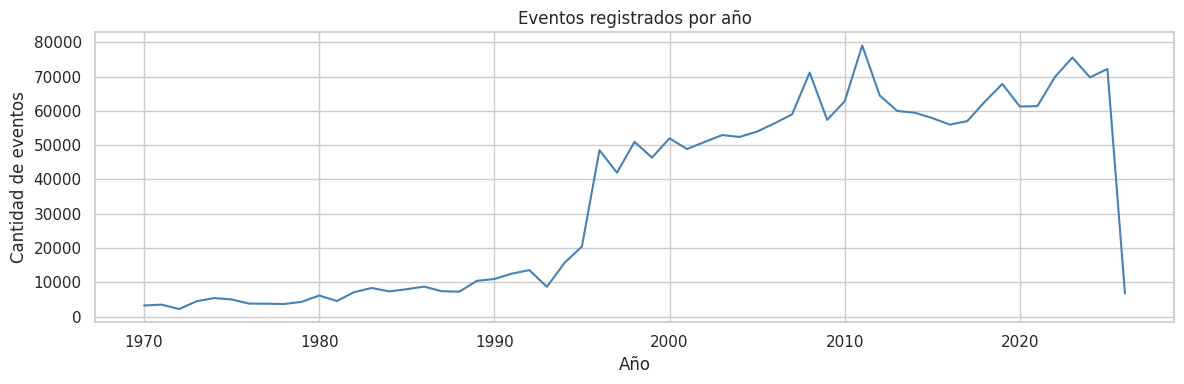

In [13]:
yearly = details.groupby('YEAR').size()
fig, ax = plt.subplots(figsize=(12, 4))
yearly.plot(ax=ax, color='steelblue')
ax.set_title('Eventos registrados por año')
ax.set_xlabel('Año'); ax.set_ylabel('Cantidad de eventos')
plt.tight_layout(); plt.show()

> Nota: el salto a partir de 1996 refleja el cambio de NOAA en la cobertura (antes solo tornados, granizo y vientos).

### 5.2 Top 15 tipos de evento

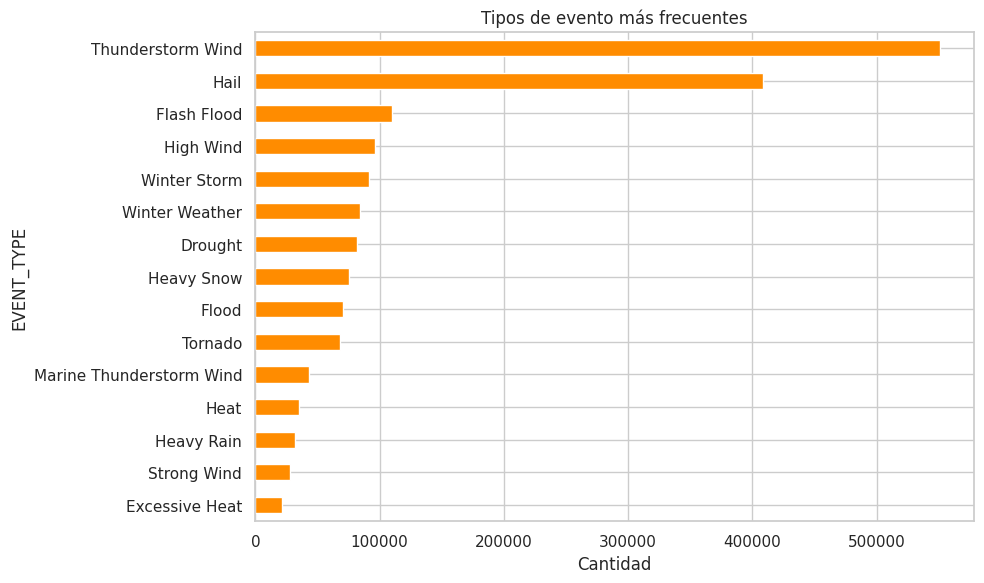

In [14]:
top_types = details['EVENT_TYPE'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
top_types.sort_values().plot.barh(ax=ax, color='darkorange')
ax.set_title('Tipos de evento más frecuentes')
ax.set_xlabel('Cantidad')
plt.tight_layout(); plt.show()

### 5.3 Estacionalidad

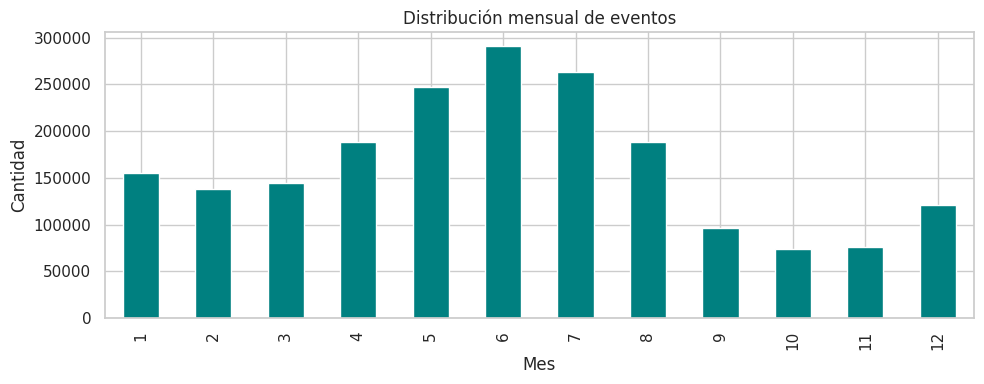

In [15]:
monthly = details.groupby('MONTH').size()
fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot.bar(ax=ax, color='teal')
ax.set_title('Distribución mensual de eventos')
ax.set_xlabel('Mes'); ax.set_ylabel('Cantidad')
plt.tight_layout(); plt.show()

### 5.4 Daños económicos

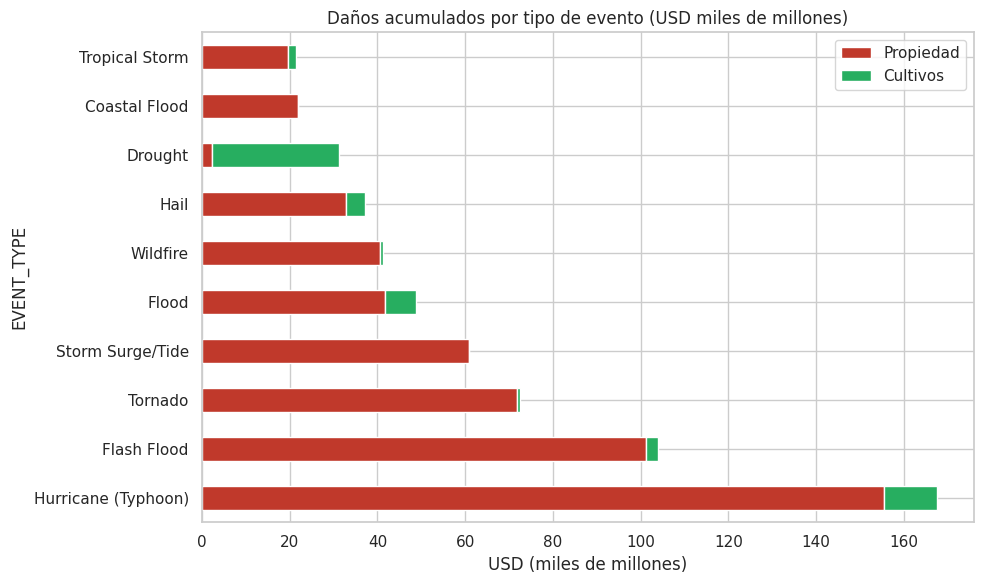

,DAMAGE_PROPERTY_USD,DAMAGE_CROPS_USD,TOTAL
EVENT_TYPE,,,
Hurricane (Typhoon),155.601029,12.033125,167.634154
Flash Flood,101.233428,2.794257,104.027684
Tornado,71.924179,0.523775,72.447954
Storm Surge/Tide,60.968115,0.000955,60.969070
Flood,41.771015,7.121078,48.892093
Wildfire,40.569482,0.710522,41.280004
Hail,32.759397,4.377658,37.137055
Drought,2.197558,29.118681,31.316239
Coastal Flood,21.931676,0.002810,21.934486


In [16]:
damage = (details.groupby('EVENT_TYPE')[['DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD']]
                 .sum()
                 .assign(TOTAL=lambda d: d.sum(axis=1))
                 .sort_values('TOTAL', ascending=False)
                 .head(10))
damage_b = damage / 1e9  # en miles de millones de USD

fig, ax = plt.subplots(figsize=(10, 6))
damage_b[['DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD']].plot.barh(
    stacked=True, ax=ax, color=['#c0392b', '#27ae60'])
ax.set_title('Daños acumulados por tipo de evento (USD miles de millones)')
ax.set_xlabel('USD (miles de millones)')
ax.legend(['Propiedad', 'Cultivos'])
plt.tight_layout(); plt.show()

damage_b

### 5.5 Víctimas

In [17]:
victim_cols = ['DEATHS_DIRECT', 'DEATHS_INDIRECT', 'INJURIES_DIRECT', 'INJURIES_INDIRECT']
victims = (details.groupby('EVENT_TYPE')[victim_cols]
                  .sum()
                  .assign(TOTAL_DEATHS=lambda d: d['DEATHS_DIRECT'] + d['DEATHS_INDIRECT'])
                  .sort_values('TOTAL_DEATHS', ascending=False)
                  .head(10))
victims

,DEATHS_DIRECT,DEATHS_INDIRECT,INJURIES_DIRECT,INJURIES_INDIRECT,TOTAL_DEATHS
EVENT_TYPE,,,,,
Tornado,3987,48,67548,291,4035
Heat,3248,749,10817,278,3997
Excessive Heat,2061,640,8035,84,2701
Flash Flood,2131,68,6521,75,2199
Rip Current,1395,9,985,19,1404
Hurricane (Typhoon),1218,166,1772,2481,1384
Thunderstorm Wind,1164,114,11759,427,1278
Winter Weather,198,888,2407,4164,1086
Lightning,954,54,5467,352,1008


### 5.6 Distribución geográfica

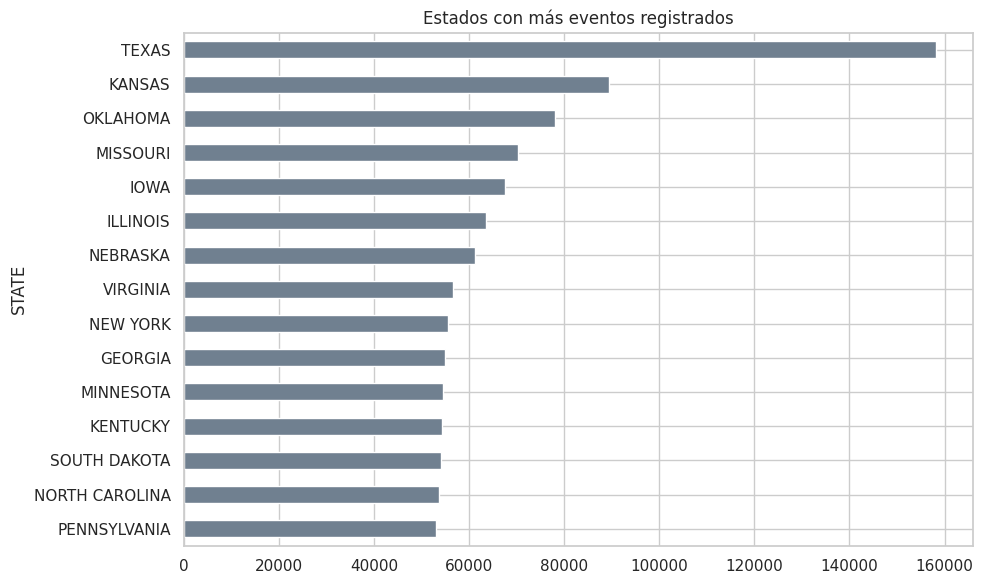

In [18]:
by_state = details['STATE'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 6))
by_state.sort_values().plot.barh(ax=ax, color='slategray')
ax.set_title('Estados con más eventos registrados')
plt.tight_layout(); plt.show()

## 6. Merge con `locations` y `fatalities`

Se vinculan los tres DataFrames mediante `EVENT_ID`. Dado que un evento puede tener múltiples ubicaciones y víctimas, el resultado se mantiene en formato largo.

In [19]:
details_geo = details.merge(
    locations[['EVENT_ID', 'LATITUDE', 'LONGITUDE', 'LOCATION']],
    on='EVENT_ID', how='left')

details_fat = details.merge(
    fatalities[['EVENT_ID', 'FATALITY_TYPE', 'FATALITY_AGE', 'FATALITY_SEX', 'FATALITY_LOCATION']],
    on='EVENT_ID', how='inner')

print(f'details_geo: {len(details_geo):,} filas (eventos × ubicaciones)')
print(f'details_fat: {len(details_fat):,} filas (solo eventos con víctimas)')

details_geo: 2,477,640 filas (eventos × ubicaciones)
details_fat: 24,539 filas (solo eventos con víctimas)


## 7. Análisis de faltantes

In [20]:
# === Análisis de valores faltantes ===
missing = pd.DataFrame({
    'n_missing': details.isna().sum(),
    'pct_missing': (details.isna().mean() * 100).round(2),
    'dtype': details.dtypes.astype(str)
})
missing = missing[missing['n_missing'] > 0].sort_values('pct_missing', ascending=False)
print(f'Columnas con faltantes: {len(missing)} de {details.shape[1]}')
missing

Columnas con faltantes: 34 de 56


,n_missing,pct_missing,dtype
CATEGORY,1982774,99.97,float64
TOR_OTHER_WFO,1979585,99.81,object
TOR_OTHER_CZ_NAME,1979593,99.81,object
TOR_OTHER_CZ_STATE,1979585,99.81,object
TOR_OTHER_CZ_FIPS,1979593,99.81,float64
TOR_F_SCALE,1916171,96.61,object
FLOOD_CAUSE,1857215,93.64,object
TOR_WIDTH,1744520,87.96,float64
TOR_LENGTH,1744520,87.96,float64
MAGNITUDE_TYPE,1438447,72.53,object


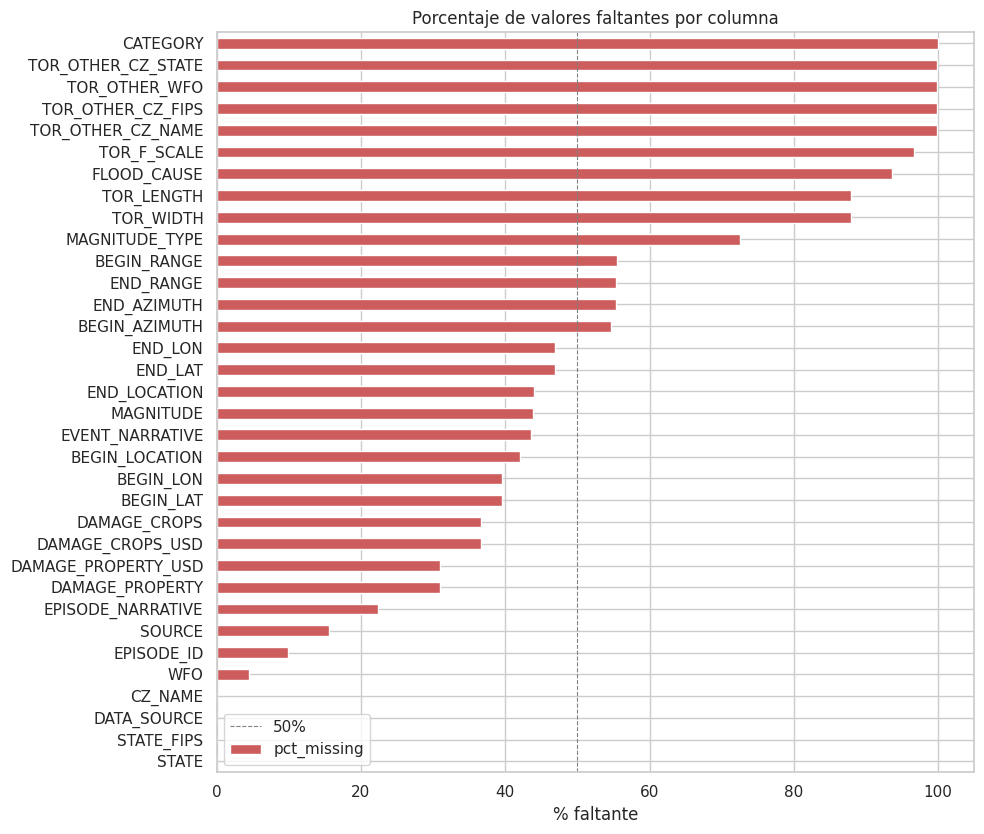

In [21]:
# Visualización
fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.25)))
missing['pct_missing'].sort_values().plot.barh(ax=ax, color='indianred')
ax.set_title('Porcentaje de valores faltantes por columna')
ax.set_xlabel('% faltante')
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, label='50%')
ax.legend()
plt.tight_layout(); plt.show()

In [22]:
# Faltantes condicionados al tipo de evento (los campos TOR_* sólo aplican a tornados)
tor_cols = [c for c in details.columns if c.startswith('TOR_')]
tornados = details[details['EVENT_TYPE'] == 'Tornado']
print(f'Eventos tipo Tornado: {len(tornados):,}')
print('\nFaltantes en campos TOR_ dentro de tornados:')
print((tornados[tor_cols].isna().mean() * 100).round(2).sort_values(ascending=False))

Eventos tipo Tornado: 67,843

Faltantes en campos TOR_ dentro de tornados:
TOR_OTHER_CZ_NAME     94.49
TOR_OTHER_CZ_FIPS     94.49
TOR_OTHER_CZ_STATE    94.47
TOR_OTHER_WFO         94.47
TOR_F_SCALE            1.01
TOR_WIDTH              0.00
TOR_LENGTH             0.00
dtype: float64


## 8. Selección y revisión de outliers

In [23]:
# === Outliers en variables numéricas clave ===
numeric_cols = ['INJURIES_DIRECT', 'INJURIES_INDIRECT',
                'DEATHS_DIRECT', 'DEATHS_INDIRECT',
                'DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD',
                'MAGNITUDE', 'TOR_LENGTH', 'TOR_WIDTH']

summary = details[numeric_cols].describe(percentiles=[.5, .9, .95, .99]).T
summary['skew'] = details[numeric_cols].skew()
summary

,count,mean,std,min,50%,90%,95%,99%,max,skew
INJURIES_DIRECT,1983334.0,0.066065,3.103756e+00,0.0,0.0,0.00,0.00,1.0,1.700000e+03,222.444378
INJURIES_INDIRECT,1983334.0,0.007981,1.810097e+00,0.0,0.0,0.00,0.00,0.0,2.400000e+03,1192.618608
DEATHS_DIRECT,1983334.0,0.010824,5.617217e-01,0.0,0.0,0.00,0.00,0.0,6.380000e+02,780.058595
DEATHS_INDIRECT,1983334.0,0.002307,9.404750e-02,0.0,0.0,0.00,0.00,0.0,5.600000e+01,190.196063
DAMAGE_PROPERTY_USD,1368445.0,436111.133282,3.591252e+07,0.0,0.0,20000.00,75000.00,1200000.0,1.790000e+10,274.203583
DAMAGE_CROPS_USD,1256430.0,56291.655487,3.093406e+06,0.0,0.0,0.00,0.00,50000.0,1.500000e+09,220.691296
MAGNITUDE,1114302.0,29.100141,3.464762e+01,0.0,40.0,60.00,62.00,74.0,2.200000e+04,234.158032
TOR_LENGTH,238814.0,0.891266,8.268994e+00,0.0,0.0,2.05,5.22,15.0,2.315000e+03,212.320925
TOR_WIDTH,238814.0,38.498447,1.429842e+02,0.0,0.0,100.00,200.00,700.0,4.576000e+03,8.361737


In [24]:
# Conteo de outliers por método IQR
def iqr_outliers(series):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((s < lo) | (s > hi)).sum()
    return pd.Series({'n_outliers': n,
                      'pct_outliers': round(n / len(s) * 100, 2),
                      'low_bound': lo, 'high_bound': hi})

outlier_report = pd.DataFrame({c: iqr_outliers(details[c]) for c in numeric_cols}).T
outlier_report

,n_outliers,pct_outliers,low_bound,high_bound
INJURIES_DIRECT,19886.0,1.00,0.00,0.00
INJURIES_INDIRECT,2954.0,0.15,0.00,0.00
DEATHS_DIRECT,11726.0,0.59,0.00,0.00
DEATHS_INDIRECT,2966.0,0.15,0.00,0.00
DAMAGE_PROPERTY_USD,228381.0,16.69,-3000.00,5000.00
DAMAGE_CROPS_USD,38847.0,3.09,0.00,0.00
MAGNITUDE,101.0,0.01,-75.50,128.50
TOR_LENGTH,49209.0,20.61,-0.15,0.25
TOR_WIDTH,30093.0,12.60,-30.00,50.00


In [25]:
# Top 10 eventos más extremos por daño y por víctimas
print('=== Top 10 eventos por daño a la propiedad ===')
cols_show = ['BEGIN_DATE_TIME', 'STATE', 'EVENT_TYPE',
             'DAMAGE_PROPERTY_USD', 'DEATHS_DIRECT', 'INJURIES_DIRECT']
top_damage = details.nlargest(10, 'DAMAGE_PROPERTY_USD')[cols_show]
print(top_damage.to_string())

print('\n=== Top 10 eventos por muertes directas ===')
top_deaths = details.nlargest(10, 'DEATHS_DIRECT')[cols_show]
print(top_deaths.to_string())

=== Top 10 eventos por daño a la propiedad ===
            BEGIN_DATE_TIME       STATE           EVENT_TYPE  DAMAGE_PROPERTY_USD  DEATHS_DIRECT  INJURIES_DIRECT
679205  2005-08-29 02:00:00   LOUISIANA     Storm Surge/Tide         1.790000e+10              0                0
1469096 2018-11-08 06:33:00  CALIFORNIA             Wildfire         1.700000e+10             86               12
692473  2005-10-24 07:00:00     FLORIDA  Hurricane (Typhoon)         1.000000e+10              1                0
1433655 2017-08-26 22:00:00       TEXAS          Flash Flood         1.000000e+10              3                0
1434270 2017-08-26 21:45:00       TEXAS          Flash Flood         1.000000e+10             36                0
1433489 2017-08-26 18:40:00       TEXAS          Flash Flood         8.000000e+09              3                0
1100803 2012-10-29 05:00:00  NEW JERSEY        Coastal Flood         7.500000e+09              0                0
1433651 2017-08-27 20:00:00       TEXAS  

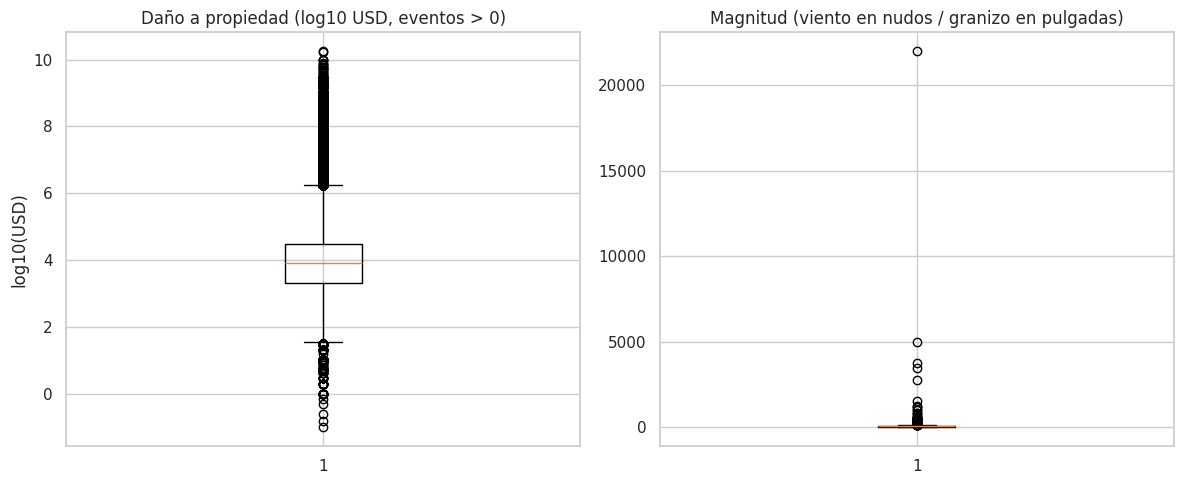

In [26]:
# Boxplots en escala logarítmica (los daños son altamente asimétricos)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

dmg = details.loc[details['DAMAGE_PROPERTY_USD'] > 0, 'DAMAGE_PROPERTY_USD']
axes[0].boxplot(np.log10(dmg), vert=True)
axes[0].set_title('Daño a propiedad (log10 USD, eventos > 0)')
axes[0].set_ylabel('log10(USD)')

mag = details['MAGNITUDE'].dropna()
axes[1].boxplot(mag, vert=True)
axes[1].set_title('Magnitud (viento en nudos / granizo en pulgadas)')

plt.tight_layout(); plt.show()

## 9. Análisis de faltantes en variables de daño

Antes de construir cualquier target basado en daño económico, es imprescindible distinguir entre **daño cero** (el evento no causó daño) y **daño no reportado** (faltante genuino). Tras la corrección del parseo, los vacíos se conservan como `NaN` en las columnas `*_USD`.

> **Nota:** la detección de faltantes se hace con `.isna()` sobre las columnas `*_USD` ya parseadas, no comparando texto sobre las columnas crudas. Las columnas originales son de tipo `string` y sus nulos (`pd.NA`) no se detectan de forma fiable con `.astype(str)`, lo que produciría un falso 0% de faltantes.


In [27]:
# === 1. Faltante (no reportado) vs. cero explícito en las columnas de daño ===
# Usamos las columnas *_USD ya parseadas: NaN = no reportado, 0.0 = cero explícito.
# (Comparar strings con .astype(str) NO detecta pd.NA correctamente -> da 0% falso.)
for col in ['DAMAGE_PROPERTY', 'DAMAGE_CROPS']:
    usd = details[f'{col}_USD']
    n_missing = usd.isna().sum()
    n_zero    = (usd == 0).sum()
    n_valid   = (usd > 0).sum()
    print(f'{col}:')
    print(f'  No reportado (NaN) : {n_missing:>9,} ({n_missing/len(details)*100:5.1f}%)')
    print(f'  Cero explícito     : {n_zero:>9,} ({n_zero/len(details)*100:5.1f}%)')
    print(f'  Valor > 0          : {n_valid:>9,} ({n_valid/len(details)*100:5.1f}%)\n')

# Coherencia con la sección 8: estos NaN deben coincidir con los de details.isna()
print('Chequeo de coherencia con sección 8:')
for col in ['DAMAGE_PROPERTY_USD', 'DAMAGE_CROPS_USD']:
    print(f'  {col}: {details[col].isna().sum():,} NaN '
          f'({details[col].isna().mean()*100:.1f}%)')

DAMAGE_PROPERTY:
  No reportado (NaN) :   614,889 ( 31.0%)
  Cero explícito     :   931,571 ( 47.0%)
  Valor > 0          :   436,874 ( 22.0%)

DAMAGE_CROPS:
  No reportado (NaN) :   726,904 ( 36.7%)
  Cero explícito     : 1,217,583 ( 61.4%)
  Valor > 0          :    38,847 (  2.0%)

Chequeo de coherencia con sección 8:
  DAMAGE_PROPERTY_USD: 614,889 NaN (31.0%)
  DAMAGE_CROPS_USD: 726,904 NaN (36.7%)


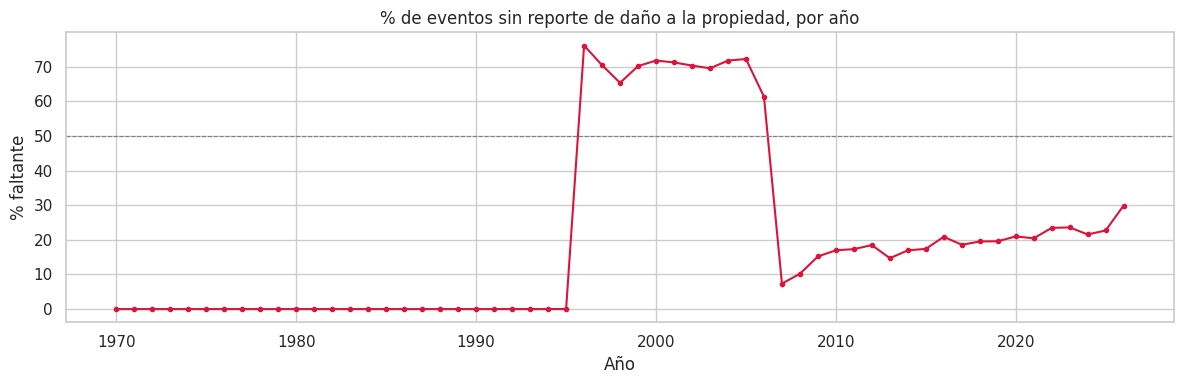

In [28]:
# === 2. Evolución temporal del reporte de daño ===
# _missing = True cuando el daño a la propiedad NO fue reportado (NaN en la col parseada)
tmp = details.assign(_missing=details['DAMAGE_PROPERTY_USD'].isna())
missing_by_year = tmp.groupby('YEAR')['_missing'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
missing_by_year.plot(ax=ax, color='crimson', marker='o', markersize=3)
ax.set_title('% de eventos sin reporte de daño a la propiedad, por año')
ax.set_xlabel('Año'); ax.set_ylabel('% faltante')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout(); plt.show()

In [29]:
# === 3. ¿El faltante de daño depende del tipo de evento? ===
tmp = details.assign(_missing=details['DAMAGE_PROPERTY_USD'].isna())
missing_by_type = (tmp.groupby('EVENT_TYPE')['_missing']
                      .agg(pct_missing='mean', n='size'))
missing_by_type['pct_missing'] *= 100
missing_by_type = missing_by_type.sort_values('pct_missing', ascending=False)

print('Tipos de evento con mayor % de daño NO reportado (top 15):')
print(missing_by_type.head(15).round(1))
print('\nTipos con MENOR % de faltante (mejor cobertura):')
print(missing_by_type.tail(10).round(1))

Tipos de evento con mayor % de daño NO reportado (top 15):
                  pct_missing       n
EVENT_TYPE                           
Northern Lights         100.0       8
Volcanic Ash             92.9      70
Cold/Wind Chill          54.3   18782
Sleet                    51.8     859
Ice Storm                47.0   12632
Heat                     46.1   34898
Heavy Snow               45.4   75693
Blizzard                 42.5   17040
Marine Hail              41.8     856
Winter Storm             41.8   91543
Drought                  41.3   81886
Waterspout               41.0    6235
Hail                     40.3  408868
Dense Fog                39.6   17576
Storm Surge/Tide         39.1    1656

Tipos con MENOR % de faltante (mejor cobertura):
                            pct_missing    n
EVENT_TYPE                                  
Marine High Wind                    9.5  976
Marine Tropical Storm               9.3  603
Marine Strong Wind                  7.2  166
Lakeshore Flood     

### Lectura e implicancias

Las celdas anteriores responden a las preguntas que condicionan el diseño del target:

1. **No reportado vs. cero**: si la proporción de no reportados es alta, no se puede tratar el faltante como "Sin daño".
2. **Evolución temporal**: si el reporte cambia bruscamente en el tiempo, un split temporal de train/test mezclaría definiciones distintas de la clase base.
3. **Por tipo de evento**: algunos tipos (p. ej. eventos marinos o de baja visibilidad) casi nunca reportan daño y podrían requerir tratamiento aparte.

A partir de estos números se elige una de tres estrategias: (a) tratar el faltante como "Sin daño", (b) excluir los no reportados del problema de daño, o (c) modelar en dos etapas (primero "¿hubo daño?", luego magnitud condicionada). La decisión se toma con los datos a la vista, antes de construir el target.

## 10. Feature engineering para el dataset limpio maestro

En esta etapa se crean únicamente variables **determinísticas**: dependen de la información disponible en cada fila y no requieren aprender estadísticas globales del dataset.

No se aplican todavía:

- imputación con media, mediana o moda;
- one-hot encoding;
- escalado;
- target encoding;
- selección supervisada de features;
- transformaciones calculadas con estadísticas de todo el dataset.

Estas operaciones deben realizarse después del split, dentro del pipeline de modelado.

In [30]:
# === Feature Engineering: setup ===
# Trabajamos sobre una copia para preservar el DataFrame consolidado original.
df = details.copy()
print(f'Filas: {len(df):,} | Columnas iniciales: {df.shape[1]}')

Filas: 1,983,334 | Columnas iniciales: 56


### 10.1 Features temporales

Se conservan variables temporales relativamente amplias (`YEAR`, `SEASON`, `DECADE`) porque todavía no corresponde descartarlas sin evaluar su aporte en los modelos. Las variables parcialmente redundantes también pueden conservarse en el dataset maestro y compararse mediante *ablation studies* más adelante.

In [31]:
# === 10.1 Features temporales ===
df['HOUR']         = df['BEGIN_DATE_TIME'].dt.hour
df['DAY_OF_WEEK']  = df['BEGIN_DATE_TIME'].dt.dayofweek      # 0 = lunes
df['DAY_OF_YEAR']  = df['BEGIN_DATE_TIME'].dt.dayofyear
df['IS_WEEKEND']   = df['DAY_OF_WEEK'].isin([5, 6]).astype(int)
df['DECADE']       = (df['YEAR'] // 10 * 10).astype('Int64')

# Estación meteorológica del hemisferio norte
def get_season(month):
    if month in (12, 1, 2):
        return 'Winter'
    if month in (3, 4, 5):
        return 'Spring'
    if month in (6, 7, 8):
        return 'Summer'
    return 'Fall'

df['SEASON'] = df['MONTH'].apply(get_season)

# Franja horaria
def time_of_day(hour):
    if pd.isna(hour):
        return np.nan
    if 0 <= hour < 6:
        return 'Night'
    if 6 <= hour < 12:
        return 'Morning'
    if 12 <= hour < 18:
        return 'Afternoon'
    return 'Evening'

df['TIME_OF_DAY'] = df['HOUR'].apply(time_of_day)

# Duración original en minutos.
# No se aplica clipping global en esta notebook: cualquier límite debe aprenderse con train.
duration = (df['END_DATE_TIME'] - df['BEGIN_DATE_TIME']).dt.total_seconds() / 60
df['DURATION_MIN'] = duration.where(duration >= 0, np.nan)

# Indicador histórico: NOAA amplió la cobertura de eventos a partir de 1996.
df['POST_1996'] = (df['YEAR'] >= 1996).astype(int)

print('Features temporales agregadas:')
print(df[['YEAR', 'MONTH', 'HOUR', 'DAY_OF_WEEK', 'IS_WEEKEND', 'SEASON',
          'TIME_OF_DAY', 'DURATION_MIN', 'DECADE', 'POST_1996']].head())

Features temporales agregadas:
   YEAR  MONTH  HOUR  DAY_OF_WEEK  IS_WEEKEND  SEASON TIME_OF_DAY  \
0  1970      9    16            4           0    Fall   Afternoon   
1  1970     10    16            3           0    Fall   Afternoon   
2  1970      6    16            3           0  Summer   Afternoon   
3  1970      6    22            3           0  Summer     Evening   
4  1970      7    21            2           0  Summer     Evening   

   DURATION_MIN  DECADE  POST_1996  
0           0.0    1970          0  
1           0.0    1970          0  
2           0.0    1970          0  
3           0.0    1970          0  
4           0.0    1970          0  


### 10.2 Features geográficas

`CZ_TYPE` ya distingue entre:

- `C`: county/parish;
- `Z`: forecast zone;
- `M`: marine.

Por eso no se crean `IS_MARINE` ni `IS_ZONE_FORECAST`: serían redundantes. Si se utiliza un modelo que requiere variables numéricas, `CZ_TYPE` podrá codificarse mediante OHE después del split.

In [32]:
# === 10.2 Features geográficas ===

# Región climática aproximada a partir del estado.
REGION_MAP = {
    # Tornado Alley
    'TEXAS': 'Tornado Alley', 'OKLAHOMA': 'Tornado Alley', 'KANSAS': 'Tornado Alley',
    'NEBRASKA': 'Tornado Alley', 'SOUTH DAKOTA': 'Tornado Alley',
    # Dixie Alley / Sureste
    'MISSISSIPPI': 'Southeast', 'ALABAMA': 'Southeast', 'GEORGIA': 'Southeast',
    'TENNESSEE': 'Southeast', 'ARKANSAS': 'Southeast', 'LOUISIANA': 'Southeast',
    'FLORIDA': 'Southeast', 'SOUTH CAROLINA': 'Southeast', 'NORTH CAROLINA': 'Southeast',
    'KENTUCKY': 'Southeast',
    # Medio Oeste
    'MISSOURI': 'Midwest', 'IOWA': 'Midwest', 'ILLINOIS': 'Midwest',
    'INDIANA': 'Midwest', 'OHIO': 'Midwest', 'MICHIGAN': 'Midwest',
    'WISCONSIN': 'Midwest', 'MINNESOTA': 'Midwest', 'NORTH DAKOTA': 'Midwest',
    # Noreste
    'NEW YORK': 'Northeast', 'PENNSYLVANIA': 'Northeast', 'NEW JERSEY': 'Northeast',
    'MASSACHUSETTS': 'Northeast', 'CONNECTICUT': 'Northeast', 'MAINE': 'Northeast',
    'NEW HAMPSHIRE': 'Northeast', 'VERMONT': 'Northeast', 'RHODE ISLAND': 'Northeast',
    'MARYLAND': 'Northeast', 'DELAWARE': 'Northeast', 'VIRGINIA': 'Northeast',
    'WEST VIRGINIA': 'Northeast', 'DISTRICT OF COLUMBIA': 'Northeast',
    # Oeste / Montañas
    'COLORADO': 'West', 'WYOMING': 'West', 'MONTANA': 'West', 'IDAHO': 'West',
    'UTAH': 'West', 'NEVADA': 'West', 'ARIZONA': 'West', 'NEW MEXICO': 'West',
    'CALIFORNIA': 'West Coast', 'OREGON': 'West Coast', 'WASHINGTON': 'West Coast',
    # No contiguos
    'ALASKA': 'Non-Contiguous', 'HAWAII': 'Non-Contiguous',
}

df['REGION'] = df['STATE'].map(REGION_MAP).fillna('Other/Marine')

# Distancia haversine entre el punto inicial y final cuando ambos existen.
def haversine_km(lat1, lon1, lat2, lon2):
    radius_km = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * radius_km * np.arcsin(np.sqrt(a))

track_mask = df[['BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON']].notna().all(axis=1)
df['TRACK_DISTANCE_KM'] = np.nan
df.loc[track_mask, 'TRACK_DISTANCE_KM'] = haversine_km(
    df.loc[track_mask, 'BEGIN_LAT'], df.loc[track_mask, 'BEGIN_LON'],
    df.loc[track_mask, 'END_LAT'],   df.loc[track_mask, 'END_LON']
)

# Flags de disponibilidad: preservan la diferencia entre cero real y dato faltante.
df['HAS_COORDINATES'] = df[['BEGIN_LAT', 'BEGIN_LON']].notna().all(axis=1).astype(int)
df['HAS_TRACK_DISTANCE'] = df['TRACK_DISTANCE_KM'].notna().astype(int)

# Grid geográfico de 1° × 1° para reducir cardinalidad sin eliminar coordenadas originales.
df['LAT_BIN'] = df['BEGIN_LAT'].round(0)
df['LON_BIN'] = df['BEGIN_LON'].round(0)

print('Distribución por región:')
print(df['REGION'].value_counts())

Distribución por región:
REGION
Midwest           459496
Southeast         441603
Tornado Alley     440813
Northeast         311364
West              183676
West Coast         62398
Other/Marine       59022
Non-Contiguous     24962
Name: count, dtype: int64


### 10.3 Features físicas

Los faltantes en variables específicas de tornados o inundaciones suelen ser **estructurales**: no necesariamente indican errores.

`MAGNITUDE_ZSCORE` no se exporta desde esta notebook. Su cálculo requiere medias y desvíos estándar por `EVENT_TYPE`; por lo tanto, debe ajustarse usando solo train en la notebook de modelado. Aquí se calcula únicamente una versión temporal para EDA.

In [33]:
# === 10.3 Features físicas ===

# Severidad ordinal del tornado a partir de TOR_F_SCALE.
def parse_fscale(value):
    if pd.isna(value):
        return np.nan
    text = str(value).upper().replace('EF', '').replace('F', '').strip()
    try:
        return int(text)
    except ValueError:
        return np.nan

df['TOR_SCALE_NUM'] = df['TOR_F_SCALE'].apply(parse_fscale)

# Área aproximada barrida por el tornado (millas × yardas → km²).
# Para eventos que no son del tipo tornado se conserva NaN: el concepto no aplica.
tornado_mask = df['EVENT_TYPE'].eq('Tornado')
df['TOR_AREA_KM2'] = np.nan
df.loc[tornado_mask, 'TOR_AREA_KM2'] = (
    df.loc[tornado_mask, 'TOR_LENGTH'] * 1.60934
    * df.loc[tornado_mask, 'TOR_WIDTH'] * 0.0009144
)

# Indicadores de Presencia.
df['HAS_MAGNITUDE'] = df['MAGNITUDE'].notna().astype(int)
df['HAS_TORNADO_DATA'] = df[['TOR_SCALE_NUM', 'TOR_LENGTH', 'TOR_WIDTH']].notna().any(axis=1).astype(int)

# IMPORTANTE
# SOLO PARA EDA: z-score por tipo de evento calculado con el dataset completo.
# NO se exporta. En modelado debe recalcularse con estadísticas aprendidas en train.

def zscore_within_group(series):
    std = series.std(ddof=0)
    if std == 0 or series.notna().sum() < 2:
        return pd.Series(np.nan, index=series.index)
    return (series - series.mean()) / std

magnitude_zscore_eda = (
    df.groupby('EVENT_TYPE')['MAGNITUDE']
      .transform(zscore_within_group)
)

print('Resumen de features físicas exportables:')
print(df[['MAGNITUDE', 'TOR_SCALE_NUM', 'TOR_LENGTH', 'TOR_WIDTH', 'TOR_AREA_KM2',
          'HAS_MAGNITUDE', 'HAS_TORNADO_DATA']].describe())
print('\nMAGNITUDE_ZSCORE temporal para EDA (no exportado):')
print(magnitude_zscore_eda.describe())

Resumen de features físicas exportables:
          MAGNITUDE  TOR_SCALE_NUM     TOR_LENGTH      TOR_WIDTH  \
count  1.114302e+06   65534.000000  238814.000000  238814.000000   
mean   2.910014e+01       0.761391       0.891266      38.498447   
std    3.464762e+01       0.906202       8.268994     142.984201   
min    0.000000e+00       0.000000       0.000000       0.000000   
25%    1.000000e+00       0.000000       0.000000       0.000000   
50%    4.000000e+01       1.000000       0.000000       0.000000   
75%    5.200000e+01       1.000000       0.100000      20.000000   
max    2.200000e+04       5.000000    2315.000000    4576.000000   

       TOR_AREA_KM2  HAS_MAGNITUDE  HAS_TORNADO_DATA  
count  67842.000000   1.983334e+06      1.983334e+06  
mean       1.334286   5.618328e-01      1.204109e-01  
std        5.156370   4.961621e-01      3.254415e-01  
min        0.000000   0.000000e+00      0.000000e+00  
25%        0.008829   0.000000e+00      0.000000e+00  
50%        0.085

### 10.4 Variables de impacto y monto de daño

Estas variables permiten analizar consecuencias humanas y construir el target económico. Se conservan en el dataset maestro por trazabilidad y para EDA, pero **no deben utilizarse automáticamente como predictores** del problema de daño económico.

En particular, `DAMAGE_REAL_2025` se utiliza para construir `DAMAGE_CLASS`; por eso debe excluirse de `X_model` en la notebook de entrenamiento.

In [34]:
# === 10.4 Variables derivadas de impacto ===
# Estas son útiles como TARGET potencial o como features para problemas relacionados.
# OJO: si las usás como features, asegurate de que el target no las contenga (leakage circular).

df['TOTAL_DEATHS']     = df['DEATHS_DIRECT'] + df['DEATHS_INDIRECT']
df['TOTAL_INJURIES']   = df['INJURIES_DIRECT'] + df['INJURIES_INDIRECT']
df['TOTAL_CASUALTIES'] = df['TOTAL_DEATHS'] + df['TOTAL_INJURIES']

# --- Daño total: se PRESERVAN los faltantes (no se aplastan a 0) ---
# Un evento se considera "con daño reportado" si AL MENOS una de las dos
# componentes (propiedad o cultivos) fue reportada. La suma ignora el NaN
# de la otra componente, pero si AMBAS son NaN el total queda NaN.
prop = df['DAMAGE_PROPERTY_USD']
crop = df['DAMAGE_CROPS_USD']
df['DAMAGE_REPORTED'] = prop.notna() | crop.notna()
df['TOTAL_DAMAGE_USD'] = prop.add(crop, fill_value=0)
df.loc[~df['DAMAGE_REPORTED'], 'TOTAL_DAMAGE_USD'] = np.nan

# Indicadores binarios listos para usar como targets en distintos problemas
df['HAS_FATALITIES']     = (df['TOTAL_DEATHS'] > 0).astype(int)
df['HAS_CASUALTIES']     = (df['TOTAL_CASUALTIES'] > 0).astype(int)
df['IS_VIOLENT_TORNADO'] = (df['TOR_SCALE_NUM'] >= 3).astype('Int64')
# IS_MAJOR_DAMAGE solo se define donde hubo reporte (NaN si no se reportó)
df['IS_MAJOR_DAMAGE'] = np.where(
    df['DAMAGE_REPORTED'], (df['TOTAL_DAMAGE_USD'] >= 1_000_000).astype(float), np.nan
)

print('Eventos con al menos una componente de daño reportada:')
print(f"  {df['DAMAGE_REPORTED'].sum():,} / {len(df):,} "
      f"({df['DAMAGE_REPORTED'].mean() * 100:.2f}%)")

Eventos con al menos una componente de daño reportada:
  1,407,565 / 1,983,334 (70.97%)


In [35]:
print('Tasas base de potenciales targets:')
for col in ['HAS_FATALITIES', 'HAS_CASUALTIES']:
    print(f'  {col:20s}: {df[col].mean()*100:.2f}%')

# IS_MAJOR_DAMAGE: tasa calculada SOLO sobre eventos con daño reportado
rep = df['DAMAGE_REPORTED']
print(f'  IS_MAJOR_DAMAGE (entre reportados): '
      f'{df.loc[rep, "IS_MAJOR_DAMAGE"].mean()*100:.2f}% '
      f'(reportados: {rep.sum():,} / {len(df):,})')

tornado_mask = df['HAS_TORNADO_DATA'] == 1
print(f'  IS_VIOLENT_TORNADO (entre tornados): '
      f'{df.loc[tornado_mask, "IS_VIOLENT_TORNADO"].mean()*100:.2f}%')

Tasas base de potenciales targets:
  HAS_FATALITIES      : 0.72%
  HAS_CASUALTIES      : 1.68%
  IS_MAJOR_DAMAGE (entre reportados): 1.52% (reportados: 1,407,565 / 1,983,334)
  IS_VIOLENT_TORNADO (entre tornados): 1.39%


## 11. Ajuste por inflación y construcción del target

Los montos históricos se expresan en USD comparables de 2025. La variable continua `DAMAGE_REAL_2025` se conserva para trazabilidad y EDA. Luego se discretiza en cinco clases ordinales mediante reglas explícitas.

> La notebook de modelado debe excluir `DAMAGE_REAL_2025`, `TOTAL_DAMAGE_USD` y cualquier variable derivada del daño al construir la matriz de predictores.

In [36]:
# === Ajuste por inflación: CPI-U promedio anual, base 2025 ===
# Fuente: https://www.in2013dollars.com/us-cpi
CPI_U = {
    1970: 38.8, 1971: 40.5, 1972: 41.8, 1973: 44.4, 1974: 49.3, 1975: 53.8,
    1976: 56.9, 1977: 60.6, 1978: 65.2, 1979: 72.6, 1980: 82.4, 1981: 90.9,
    1982: 96.5, 1983: 99.6, 1984: 103.9, 1985: 107.6, 1986: 109.6, 1987: 113.6,
    1988: 118.3, 1989: 124.0, 1990: 130.7, 1991: 136.2, 1992: 140.3, 1993: 144.5,
    1994: 148.2, 1995: 152.4, 1996: 156.9, 1997: 160.5, 1998: 163.0, 1999: 166.6,
    2000: 172.2, 2001: 177.1, 2002: 179.9, 2003: 184.0, 2004: 188.9, 2005: 195.3,
    2006: 201.6, 2007: 207.3, 2008: 215.3, 2009: 214.5, 2010: 218.1, 2011: 224.9,
    2012: 229.6, 2013: 233.0, 2014: 236.7, 2015: 237.0, 2016: 240.0, 2017: 245.1,
    2018: 251.1, 2019: 255.7, 2020: 258.8, 2021: 271.0, 2022: 292.7, 2023: 304.7,
    2024: 313.7, 2025: 322.1, 2026: 322.1,
}
CPI_BASE = CPI_U[2025]

# OJO: usar df['YEAR']; si ya la borraste, reconstruila desde BEGIN_DATE_TIME
year = df['YEAR'] if 'YEAR' in df.columns else df['BEGIN_DATE_TIME'].dt.year
cpi = year.map(CPI_U).fillna(CPI_BASE)

df['DAMAGE_REAL_2025'] = df['TOTAL_DAMAGE_USD'] * (CPI_BASE / cpi)

mask = df['TOTAL_DAMAGE_USD'] > 0
print(df.loc[mask, ['TOTAL_DAMAGE_USD', 'DAMAGE_REAL_2025']].describe(percentiles=[.5,.9,.99]).round(0))

       TOTAL_DAMAGE_USD  DAMAGE_REAL_2025
count      4.521980e+05      4.521980e+05
mean       1.476169e+06      2.320288e+06
std        6.285468e+07      9.213520e+07
min        0.000000e+00      0.000000e+00
50%        1.000000e+04      1.244600e+04
90%        2.500000e+05      3.580880e+05
99%        1.025000e+07      1.813626e+07
max        1.790000e+10      2.952171e+10


In [37]:
# === Target multiclase: nivel de daño económico ===
# Se utiliza una definición explícita para que la clase 0 contenga exclusivamente daño = 0.
damage = df['DAMAGE_REAL_2025']

conditions = [
    damage.eq(0),
    damage.gt(0) & damage.le(1e4),
    damage.gt(1e4) & damage.le(1e5),
    damage.gt(1e5) & damage.le(1e6),
    damage.gt(1e6),
]
labels = [0, 1, 2, 3, 4]

df['DAMAGE_CLASS'] = pd.Series(
    np.select(conditions, labels, default=np.nan),
    index=df.index,
    dtype='Float64'
).astype('Int64')

class_names = {
    0: 'Sin daño (= 0)',
    1: 'Menor (0-10K]',
    2: 'Moderado (10K-100K]',
    3: 'Severo (100K-1M]',
    4: 'Catastrófico (>1M)',
}

modeling_mask = df['DAMAGE_REAL_2025'].notna()
print(f'Eventos con daño reportado: {modeling_mask.sum():,}')
print(f'Eventos sin daño reportado: {(~modeling_mask).sum():,}')
print('\nDistribución del target entre eventos con daño reportado:')
dist = df.loc[modeling_mask, 'DAMAGE_CLASS'].value_counts().sort_index()
for cls, count in dist.items():
    print(f'  {cls} - {class_names[int(cls)]:24s}: {count:>9,} '
          f'({count / modeling_mask.sum() * 100:.2f}%)')

Eventos con daño reportado: 1,407,565
Eventos sin daño reportado: 575,769

Distribución del target entre eventos con daño reportado:
  0 - Sin daño (= 0)          :   955,367 (67.87%)
  1 - Menor (0-10K]           :   207,387 (14.73%)
  2 - Moderado (10K-100K]     :   159,046 (11.30%)
  3 - Severo (100K-1M]        :    58,733 (4.17%)
  4 - Catastrófico (>1M)      :    27,032 (1.92%)


## 12. Selección de columnas y exportación

Se exportan dos archivos:

1. `storm_events_clean_master.csv`: conserva todos los eventos y un conjunto amplio de variables limpias para EDA y futuros experimentos.
2. `storm_events_damage_modeling_base.csv`: contiene únicamente eventos con daño reportado y target disponible.

La selección final de predictores debe realizarse en la notebook de modelado. Algunas columnas se preservan por trazabilidad o análisis, aunque no deban ingresar a `X_model`.

In [38]:
# === Columnas del dataset limpio maestro ===
master_columns = [
    # Identificadores para auditoría y splits por episodio
    'EVENT_ID', 'EPISODE_ID',

    # Contexto del evento
    'EVENT_TYPE', 'CZ_TYPE', 'STATE', 'REGION', 'WFO', 'SOURCE',

    # Tiempo
    'YEAR', 'MONTH', 'HOUR', 'DAY_OF_WEEK', 'DAY_OF_YEAR', 'IS_WEEKEND',
    'DECADE', 'SEASON', 'TIME_OF_DAY', 'DURATION_MIN', 'POST_1996',

    # Geografía: originales + derivadas
    'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
    'LAT_BIN', 'LON_BIN', 'TRACK_DISTANCE_KM',
    'HAS_COORDINATES', 'HAS_TRACK_DISTANCE',

    # Magnitud y variables físicas
    'MAGNITUDE', 'MAGNITUDE_TYPE', 'HAS_MAGNITUDE',
    'FLOOD_CAUSE',
    'TOR_SCALE_NUM', 'TOR_LENGTH', 'TOR_WIDTH', 'TOR_AREA_KM2', 'HAS_TORNADO_DATA',

    # Consecuencias humanas: conservar para EDA; evaluar exclusión como predictores
    'TOTAL_DEATHS', 'TOTAL_INJURIES', 'TOTAL_CASUALTIES',
    'HAS_FATALITIES', 'HAS_CASUALTIES',

    # Targets económicos y trazabilidad
    'DAMAGE_REAL_2025', 'DAMAGE_CLASS',
]

master_columns = [column for column in master_columns if column in df.columns]
storm_events_clean_master = df[master_columns].copy()
storm_events_damage_modeling_base = storm_events_clean_master[
    storm_events_clean_master['DAMAGE_CLASS'].notna()
].reset_index(drop=True)

print(f'Dataset maestro: {storm_events_clean_master.shape[0]:,} filas × '
      f'{storm_events_clean_master.shape[1]} columnas')
print(f'Base para modelado de daño: {storm_events_damage_modeling_base.shape[0]:,} filas × '
      f'{storm_events_damage_modeling_base.shape[1]} columnas')
print('\nColumnas exportadas:')
for index, column in enumerate(storm_events_clean_master.columns, start=1):
    print(f'  {index:2d}. {column} ({storm_events_clean_master[column].dtype})')

Dataset maestro: 1,983,334 filas × 44 columnas
Base para modelado de daño: 1,407,565 filas × 44 columnas

Columnas exportadas:
   1. EVENT_ID (int64)
   2. EPISODE_ID (float64)
   3. EVENT_TYPE (object)
   4. CZ_TYPE (object)
   5. STATE (object)
   6. REGION (object)
   7. WFO (object)
   8. SOURCE (object)
   9. YEAR (int32)
  10. MONTH (int32)
  11. HOUR (int32)
  12. DAY_OF_WEEK (int32)
  13. DAY_OF_YEAR (int32)
  14. IS_WEEKEND (int64)
  15. DECADE (Int64)
  16. SEASON (object)
  17. TIME_OF_DAY (object)
  18. DURATION_MIN (float64)
  19. POST_1996 (int64)
  20. BEGIN_LAT (float64)
  21. BEGIN_LON (float64)
  22. END_LAT (float64)
  23. END_LON (float64)
  24. LAT_BIN (float64)
  25. LON_BIN (float64)
  26. TRACK_DISTANCE_KM (float64)
  27. HAS_COORDINATES (int64)
  28. HAS_TRACK_DISTANCE (int64)
  29. MAGNITUDE (float64)
  30. MAGNITUDE_TYPE (object)
  31. HAS_MAGNITUDE (int64)
  32. FLOOD_CAUSE (object)
  33. TOR_SCALE_NUM (float64)
  34. TOR_LENGTH (float64)
  35. TOR_WIDTH (fl

In [39]:
# === Chequeos de coherencia ===
assert storm_events_clean_master['EVENT_ID'].is_unique, 'EVENT_ID debe ser único.'
assert storm_events_damage_modeling_base['DAMAGE_CLASS'].notna().all()
assert storm_events_damage_modeling_base['DAMAGE_REAL_2025'].notna().all()
assert storm_events_damage_modeling_base.loc[
    storm_events_damage_modeling_base['DAMAGE_CLASS'] == 0,
    'DAMAGE_REAL_2025'
].eq(0).all(), 'La clase 0 debe contener únicamente daño exactamente igual a cero.'
assert 'MAGNITUDE_ZSCORE' not in storm_events_clean_master.columns
assert 'IS_MARINE' not in storm_events_clean_master.columns
assert 'IS_ZONE_FORECAST' not in storm_events_clean_master.columns

print('Chequeos superados correctamente.')

Chequeos superados correctamente.


In [40]:
# === Exportar CSV ===
master_path = OUTPUT_DIR / 'storm_events_clean_master.csv'
modeling_path = OUTPUT_DIR / 'storm_events_damage_modeling_base.csv'

storm_events_clean_master.to_csv(master_path, index=False)
storm_events_damage_modeling_base.to_csv(modeling_path, index=False)

print(f'Exportado: {master_path} ({storm_events_clean_master.shape[0]:,} filas × '
      f'{storm_events_clean_master.shape[1]} columnas)')
print(f'Exportado: {modeling_path} ({storm_events_damage_modeling_base.shape[0]:,} filas × '
      f'{storm_events_damage_modeling_base.shape[1]} columnas)')

Exportado: ../datasets/storm_events_clean_master.csv (1,983,334 filas × 44 columnas)
Exportado: ../datasets/storm_events_damage_modeling_base.csv (1,407,565 filas × 44 columnas)


---

## Resumen del pipeline

### Fuente de datos
NOAA Storm Events Database (1970–2026). Se consolidan archivos de detalles, ubicaciones y fatalidades vinculados mediante `EVENT_ID`.

### Limpieza realizada
- **Fechas:** reconstrucción desde columnas numéricas para evitar inconsistencias con años expresados con dos dígitos.
- **Daños:** parseo que distingue faltante genuino (`NaN`) de cero explícito (`0.0`).
- **Inflación:** conversión de los daños históricos a USD comparables de 2025.
- **Duplicados:** eliminación por `EVENT_ID`.

### Decisiones metodológicas relevantes
- `DAMAGE_REAL_2025` se utiliza para construir `DAMAGE_CLASS`, pero no debe ingresar como predictor.
- `MAGNITUDE_ZSCORE` se calcula solo temporalmente para EDA y no se exporta, ya que debe recalcularse con estadísticas aprendidas únicamente en train.
- `CZ_TYPE` se conserva como categórica. No se duplican sus categorías mediante `IS_MARINE` e `IS_ZONE_FORECAST`; el OHE se realizará después del split.
- Se preservan variables como `YEAR`, `SEASON`, coordenadas originales, `STATE`, `SOURCE`, `TOR_LENGTH` y `TOR_WIDTH` para poder evaluarlas mediante experimentos posteriores.
- Se agrega `HAS_TRACK_DISTANCE` para diferenciar una distancia realmente igual a cero de una distancia desconocida.

### Archivos exportados
- `storm_events_clean_master.csv`: dataset amplio para EDA y experimentación.
- `storm_events_damage_modeling_base.csv`: subconjunto con target económico disponible.

### Pendiente para notebooks posteriores
1. Definir un split temporal o por episodio antes de ajustar transformaciones.
2. Construir `X_model` excluyendo targets, consecuencias posteriores al evento e identificadores.
3. Ajustar imputación, OHE, escalado y cualquier normalización usando únicamente train.
4. Recalcular `MAGNITUDE_ZSCORE` dentro del pipeline o comparar modelos con y sin esa feature.
5. Evaluar selección de variables mediante *ablation studies*, sin descartar información útil prematuramente.
